## Fourier


In [17]:
def fft_filter(I, filter):
    If = np.fft.fft2(I)
    Is = np.fft.fftshift(If)

    I_star = Is * filter

    I_star_ishift = np.fft.ifftshift(I_star)

    I_prime_complejo = np.fft.ifft2(I_star_ishift)

    I_prime = np.abs(I_prime_complejo)

    return I_prime

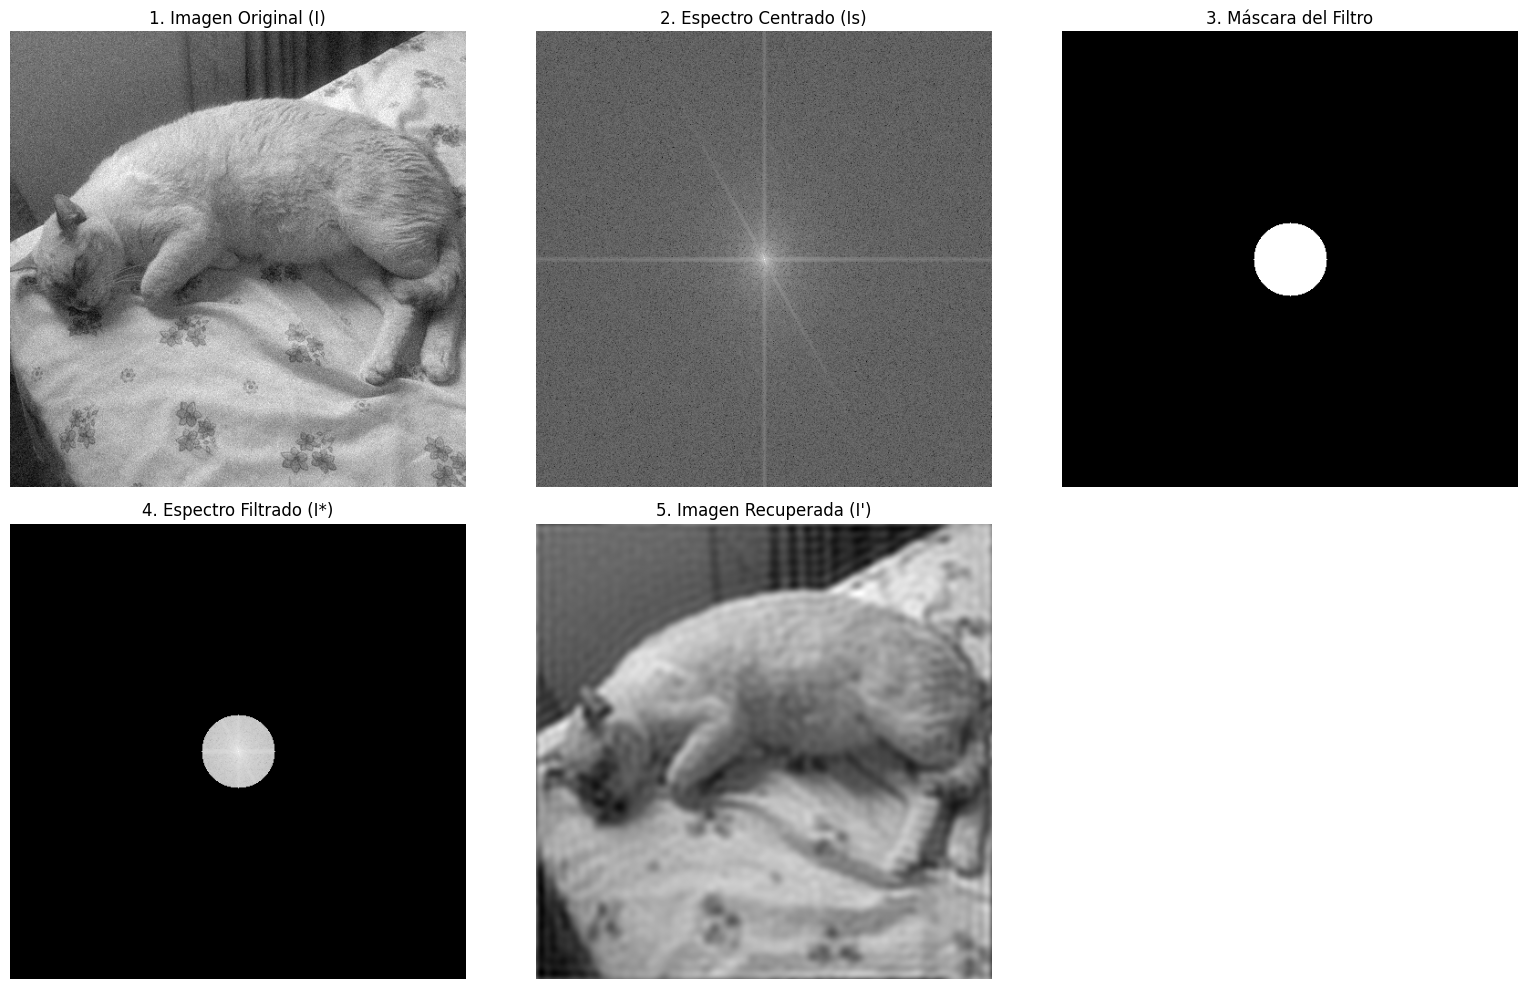

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# I = np.zeros((256, 256), dtype=np.uint8)
# cv2.circle(I, (128, 128), 40, 255, -1)

I = cv2.imread("liam3.jpeg", cv2.IMREAD_GRAYSCALE)
ruido = np.random.normal(0, 10, I.shape)
I = np.clip(I + ruido, 0, 255).astype(np.uint8)

# ---------------------------------------------------------
# Paso 1: If = FFT(I)
# ---------------------------------------------------------
# Calculamos la Transformada Rápida de Fourier 2D.
If = np.fft.fft2(I)

# ---------------------------------------------------------
# Paso 2: Is = fftshift(If)
# ---------------------------------------------------------
# Movemos las frecuencias bajas (componente cero) al centro del espectro.
Is = np.fft.fftshift(If)

# Calculamos la magnitud del espectro para poder visualizarlo
# (usamos logaritmo porque los valores centrales son demasiado grandes)
espectro_magnitud = 20 * np.log(np.abs(Is) + 1e-8)

# ---------------------------------------------------------
# Paso 3: I* = filtrar (I_star)
# ---------------------------------------------------------
# Vamos a crear y aplicar un Filtro Paso Bajo Ideal para suavizar la imagen (quitar ruido).
filas, columnas = I.shape
centro_x, centro_y = filas // 2, columnas // 2
radio = 40  # Frecuencia de corte

# Creamos la máscara del filtro (1 dentro del círculo, 0 fuera)
filtro = np.zeros((filas, columnas), np.uint8)
cv2.circle(filtro, (centro_y, centro_x), radio, 1, -1)

# Multiplicamos el espectro centrado por nuestro filtro
I_star = Is * filtro

# Espectro filtrado para visualizar
espectro_filtrado_mag = 20 * np.log(np.abs(I_star) + 1e-8)

# ---------------------------------------------------------
# Paso 4: I' = fft-1(I*) (I_prime)
# ---------------------------------------------------------
# NOTA IMPORTANTE: Antes de hacer la IFFT, debemos revertir el shift que hicimos en el paso 2.
I_star_ishift = np.fft.ifftshift(I_star)

# Aplicamos la Transformada Inversa de Fourier 2D
I_prime_complejo = np.fft.ifft2(I_star_ishift)

# La imagen resultante es compleja, tomamos el valor absoluto (la parte real)
I_prime = np.abs(I_prime_complejo)


plt.figure(figsize=(16, 10))

plt.subplot(2, 3, 1)
plt.imshow(I, cmap="gray")
plt.title("1. Imagen Original (I)")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(espectro_magnitud, cmap="gray")
plt.title("2. Espectro Centrado (Is)")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(filtro, cmap="gray")
plt.title("3. Máscara del Filtro")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(espectro_filtrado_mag, cmap="gray")
plt.title("4. Espectro Filtrado (I*)")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(I_prime, cmap="gray")
plt.title("5. Imagen Recuperada (I')")
plt.axis("off")

plt.tight_layout()
plt.show()

## Image FFT


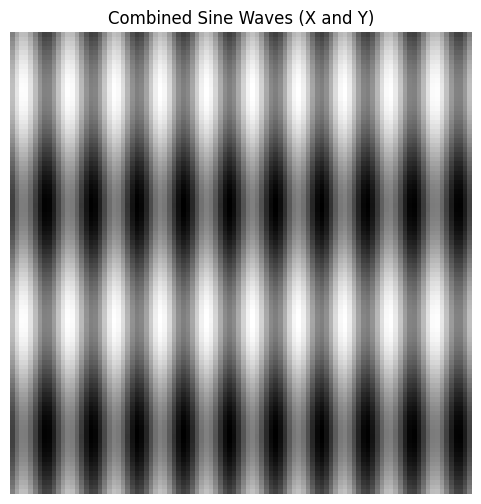

In [18]:
import numpy as np
import matplotlib.pyplot as plt

width = 100
height = 100

x = np.linspace(0, 2 * np.pi, width)
y = np.linspace(0, 2 * np.pi, height)
X, Y = np.meshgrid(x, y)

freq_x = 10
freq_y = 2
ampl_x = 0.5
ampl_y = 0.5

sin_wave_x = ampl_x * np.sin(freq_x * X)
sin_wave_y = ampl_y * np.sin(freq_y * Y)

combined_wave = sin_wave_x + sin_wave_y

combined_wave = (combined_wave - combined_wave.min()) / (
    combined_wave.max() - combined_wave.min()
)

plt.figure(figsize=(6, 6))
plt.imshow(combined_wave, cmap="gray")  # Using grayscale colormap
plt.title("Combined Sine Waves (X and Y)")
plt.axis("off")
plt.show()

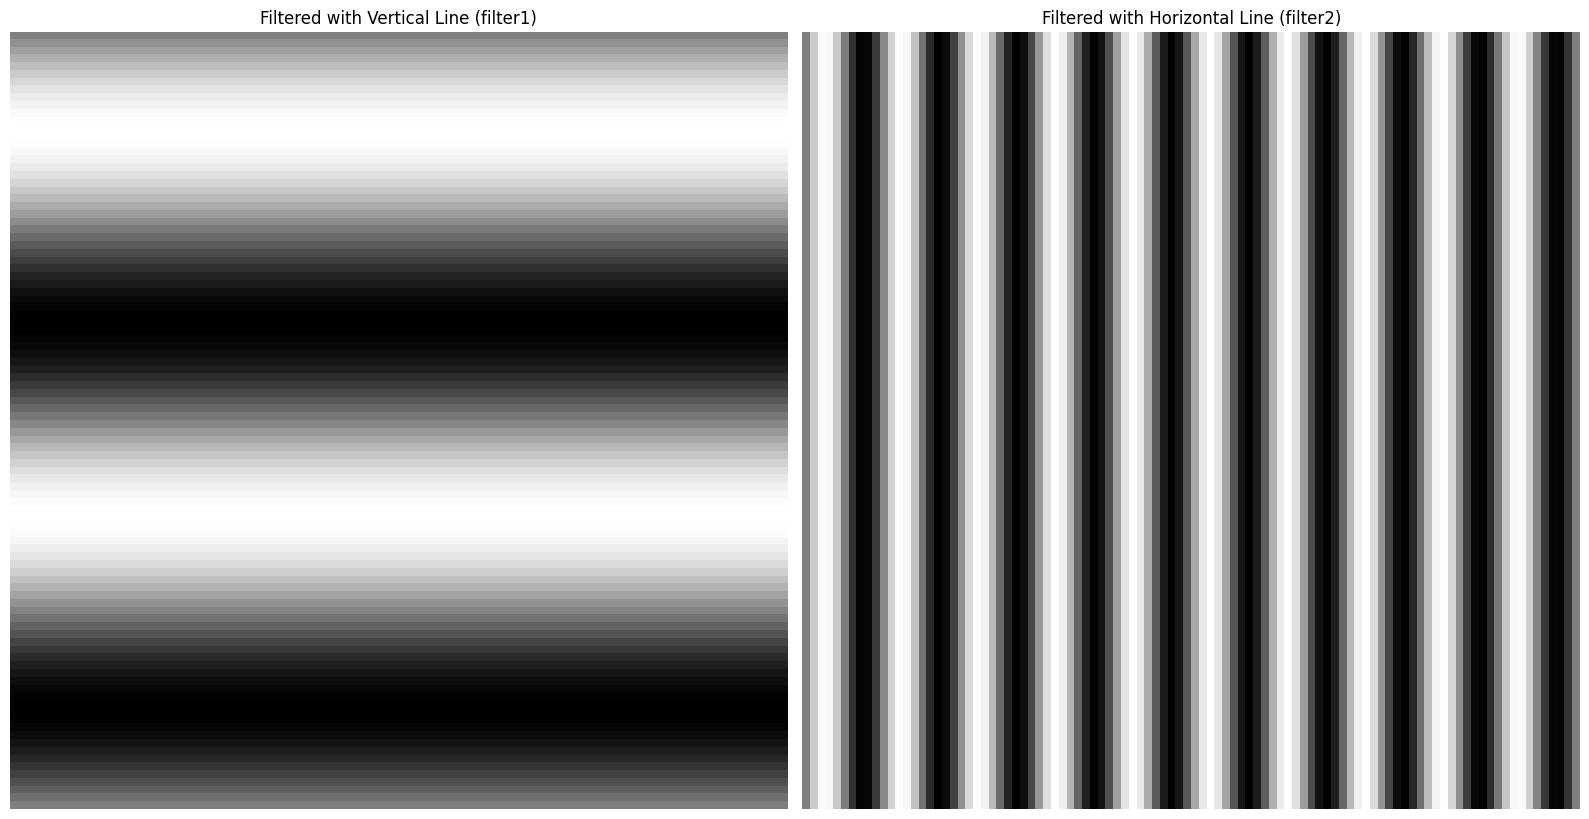

In [ ]:
filter1 = np.zeros((height, width), dtype=np.uint8)
filter1[:, width // 2] = 1

filter2 = np.zeros((height, width), dtype=np.uint8)
filter2[height // 2, :] = 1

plt.figure(figsize=(16, 10))

plt.subplot(2, 3, 1)
plt.imshow(combined_wave, cmap="gray")
plt.title("Original Combined Wave")


plt.subplot(2, 3, 2)
result1 = fft_filter(combined_wave, filter1)
plt.imshow(result1, cmap="gray")
plt.title("Filtered with Vertical Line (filter1)")
plt.axis("off")

plt.subplot(2, 3, 3)
result2 = fft_filter(combined_wave, filter2)
plt.imshow(result2, cmap="gray")
plt.title("Filtered with Horizontal Line (filter2)")
plt.axis("off")

plt.tight_layout()
plt.show()

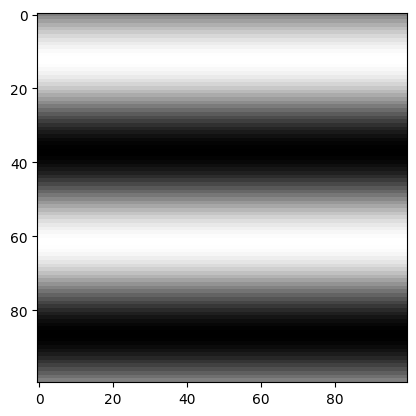

In [20]:
result = fft_filter(combined_wave, filter)

plt.imshow(result, cmap="gray")